In [59]:
pip install cmdstanpy


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [60]:

import cmdstanpy
import numpy as np
import pandas as pd 

In [61]:
df = pd.read_csv("forstmann.csv")

df["correct"] = df.apply(lambda row: 1 if row["S"] == row["R"] else 0,axis = 1)
df['participant_id'], participant_labels = pd.factorize(df['subjects'])
df['participant_id'] += 1  

sat_map = {"speed":1,"neutral":2,"accuracy":3}
df["sat_int"] = df["E"].map(sat_map)
df["pc"] = (df["participant_id"]-1)*3 + df["sat_int"]
df

,subjects,E,S,R,rt,correct,participant_id,sat_int,pc
0,as1t,accuracy,right,right,0.4319,1,1,3,3
1,as1t,speed,right,right,0.5015,1,1,1,1
2,as1t,speed,left,left,0.3104,1,1,1,1
3,as1t,accuracy,right,right,0.4809,1,1,3,3
4,as1t,accuracy,left,left,0.3415,1,1,3,3
...,...,...,...,...,...,...,...,...,...
15813,zk1t,speed,right,right,0.3244,1,19,1,55
15814,zk1t,neutral,left,left,0.5800,1,19,2,56
15815,zk1t,neutral,left,left,0.9199,1,19,2,56
15816,zk1t,accuracy,left,right,0.6314,0,19,3,57


In [62]:
max_rt = (df.groupby(['participant_id','sat_int'])["rt"].max())
max_rt

participant_id  sat_int
1               1          0.7979
                2          1.1555
                3          0.9912
2               1          0.6489
                2          1.1242
                3          1.3960
3               1          0.8129
                2          1.4322
                3          1.4769
4               1          0.7022
                2          0.8110
                3          1.0007
5               1          0.6481
                2          0.9952
                3          1.4364
6               1          0.9039
                2          0.9092
                3          1.3001
7               1          1.2651
                2          1.2043
                3          1.4077
8               1          1.2592
                2          1.3809
                3          1.3834
9               1          1.3234
                2          1.1941
                3          1.2196
10              1          0.8278
                2       

In [ ]:
N_correct = len(df[df["correct"] == 1])
N_false = len(df[df["correct"] == 0])
P = 19
rt_correct = list(df[df["correct"]==1]["rt"])
rt_false = list(df[df["correct"]==0]["rt"])
pc_correct = list(df[df["correct"]==1]["pc"])
pc_false = list(df[df["correct"]==0]["pc"])

t0_hi = (
    df.groupby('pc')['rt']
    .quantile(0.05)
    .reindex(range(1, 3 * P + 1))  # 57, not 19
)




print(N_correct,N_false,rt_false)
data = {"N_correct":N_correct,"N_false":N_false,"P":P,
        "rt_correct":rt_correct,"rt_false":rt_false,
        "pc_correct":pc_correct,"pc_false":pc_false,"max_rt":max_rt,"t0_hi":t0_hi}

from cmdstanpy import CmdStanModel

model = CmdStanModel(stan_file='SRDM_hierarchical.stan')





13294 2524 [0.3111, 0.4118, 0.4343, 0.3286, 0.4872, 0.321, 0.4179, 0.6087, 0.3561, 0.5971, 0.4731, 0.7205, 0.4949, 0.4222, 0.3304, 0.5636, 0.2693, 0.2952, 0.3923, 0.4207, 0.3172, 0.3472, 0.4619, 0.5878, 0.4227, 0.4178, 0.7814, 0.4248, 0.4782, 0.2508, 0.3542, 0.2742, 0.4646, 0.5855, 0.4592, 0.5876, 0.4358, 0.3632, 0.5256, 0.6568, 0.6033, 0.5813, 0.3321, 0.6356, 0.3355, 0.6077, 0.6896, 0.4748, 0.4662, 0.5469, 0.4984, 0.3845, 0.4819, 0.4135, 0.4852, 0.4698, 0.4768, 0.4402, 0.6428, 0.4315, 0.6628, 0.7461, 0.4767, 0.5287, 0.6025, 0.5145, 0.8565, 0.4453, 0.5473, 0.4656, 0.4555, 0.6289, 0.3824, 0.4643, 0.485, 0.301, 0.3467, 0.4999, 0.3045, 0.5888, 0.5423, 0.4593, 0.5522, 0.4058, 0.5459, 0.4679, 0.6829, 0.4227, 0.6181, 0.4917, 0.3587, 0.3434, 0.5736, 0.388, 0.4163, 0.6115, 0.4535, 0.4528, 0.3136, 0.3105, 0.3589, 0.3007, 0.3154, 0.2692, 0.449, 0.3353, 0.3959, 0.4254, 0.4713, 0.5634, 0.3659, 0.369, 0.4745, 0.4393, 0.4981, 0.3239, 0.7392, 0.4319, 0.3065, 0.433, 0.6091, 0.3335, 0.5856, 0.4238, 0.2

In [ ]:


init_values = {
    'mu_c': [0.0]*3, 'sigma_c': [0.3]*3,
    'mu_logd': [np.log(1.5)]*3, 'sigma_logd': [0.2]*3,
    'mu_logr': [np.log(4.5)]*3, 'sigma_logr': [0.2]*3,
    'mu_logB': [0.0]*3, 'sigma_logB': [0.2]*3,
    'mu_t0_logit': [0.0]*3, 'sigma_t0_logit': [0.2]*3,
    'mu_lapse_logit': [-3.9]*3, 'sigma_lapse_logit': [0.2]*3,
    'c_z': [0.0]*(3*P), 'logd_z': [0.0]*(3*P), 'logr_z': [0.0]*(3*P),
    'logB_z': [0.0]*(3*P), 't0_z': [0.0]*(3*P), 'lapse_z': [0.0]*(3*P),
}
fit = model.sample(data=data,chains = 4, parallel_chains=4, inits=init_values,show_console=True,metric='dense_e')



00:19:15 - cmdstanpy - INFO - Chain [1] start processing
00:19:15 - cmdstanpy - INFO - Chain [2] start processing
00:19:15 - cmdstanpy - INFO - Chain [3] start processing
00:19:15 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = dense_e
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/tmptb782vpm/rmmlxn1e.json
Chain [1] init = /var/folders/g5/d_krhx3

01:34:50 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] 
Chain [1] Elapsed Time: 3896.66 seconds (Warm-up)
Chain [1] 637.412 seconds (Sampling)
Chain [1] 4534.07 seconds (Total)
Chain [1] 
Chain [1] 
Chain [3] Iteration: 1100 / 2000 [ 55%]  (Sampling)
Chain [2] Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain [4] Iteration: 1500 / 2000 [ 75%]  (Sampling)
Chain [2] Iteration: 1700 / 2000 [ 85%]  (Sampling)
Chain [3] Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain [4] Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain [3] Iteration: 1300 / 2000 [ 65%]  (Sampling)
Chain [3] Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain [4] Iteration: 1700 / 2000 [ 85%]  (Sampling)
Chain [3] Iteration: 1500 / 2000 [ 75%]  (Sampling)
Chain [2] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [3] Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain [4] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [2] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [3] Iteration: 1700 / 2000 [ 85%]  (Sampling)
Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)


01:46:18 - cmdstanpy - INFO - Chain [2] done processing


...

01:49:59 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] 
Chain [4] Elapsed Time: 3751.39 seconds (Warm-up)
Chain [4] 1691.9 seconds (Sampling)
Chain [4] 5443.29 seconds (Total)
Chain [4] 
Chain [4] 
Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)


01:51:08 - cmdstanpy - INFO - Chain [3] done processing
01:51:08 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: log_mix: lambda2 is nan, but must be not nan! (in 'SRDM_hierarchical.stan', line 152, column 8 to column 68)
	Exception: log_mix: lambda2 is nan, but must be not nan! (in 'SRDM_hierarchical.stan', line 152, column 8 to column 68)
	Exception: log_mix: lambda2 is nan, but must be not nan! (in 'SRDM_hierarchical.stan', line 152, column 8 to column 68)
	Exception: Phi: x is nan, but must be not nan! (in 'SRDM_hierarchical.stan', line 142, column 4 to line 145, column 81)
	Exception: Phi: x is nan, but must be not nan! (in 'SRDM_hierarchical.stan', line 142, column 4 to line 145, column 81)
	Exception: log_mix: lambda2 is nan, but must be not nan! (in 'SRDM_hierarchical.stan', line 152, column 8 to column 68)
Exception: log_mix: lambda2 is nan, but must be not nan! (in 'SRDM_hierarchical.stan', line 152, column 8 to column 68)
	Exception: log_mix: lambda2 is n

Chain [3] 
Chain [3] Elapsed Time: 4485.27 seconds (Warm-up)
Chain [3] 1027.59 seconds (Sampling)
Chain [3] 5512.85 seconds (Total)
Chain [3] 
Chain [3] 


01:51:09 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 1000 divergent transitions (100.0%)
	Chain 2 had 1000 divergent transitions (100.0%)
	Chain 3 had 1000 divergent transitions (100.0%)
	Chain 4 had 1000 divergent transitions (100.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [72]:
idata

Inference data with groups:
	> posterior
	> sample_stats

In [78]:
print(az.summary(idata, var_names=["mu_c", "sigma_c", "mu_logd", "sigma_logd",
                               "mu_logr", "sigma_logr", "mu_logB", "sigma_logB",
                               "mu_t0_logit", "sigma_t0_logit",
                                                              "mu_lapse_logit", "sigma_lapse_logit"]))

                       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
mu_c[0]              -0.382  0.043  -0.460   -0.302      0.009    0.002   
mu_c[1]               0.061  0.093  -0.099    0.250      0.023    0.005   
mu_c[2]               0.225  0.095   0.055    0.409      0.031    0.018   
sigma_c[0]            0.181  0.046   0.103    0.270      0.014    0.003   
sigma_c[1]            0.288  0.066   0.174    0.409      0.013    0.005   
sigma_c[2]            0.376  0.065   0.264    0.506      0.015    0.004   
mu_logd[0]            0.413  0.101   0.234    0.616      0.029    0.007   
mu_logd[1]            0.445  0.105   0.241    0.636      0.021    0.005   
mu_logd[2]            0.612  0.098   0.422    0.795      0.022    0.009   
sigma_logd[0]         0.389  0.077   0.261    0.541      0.018    0.003   
sigma_logd[1]         0.478  0.085   0.331    0.630      0.013    0.006   
sigma_logd[2]         0.406  0.072   0.279    0.541      0.016    0.003   
mu_logr[0]            1.6

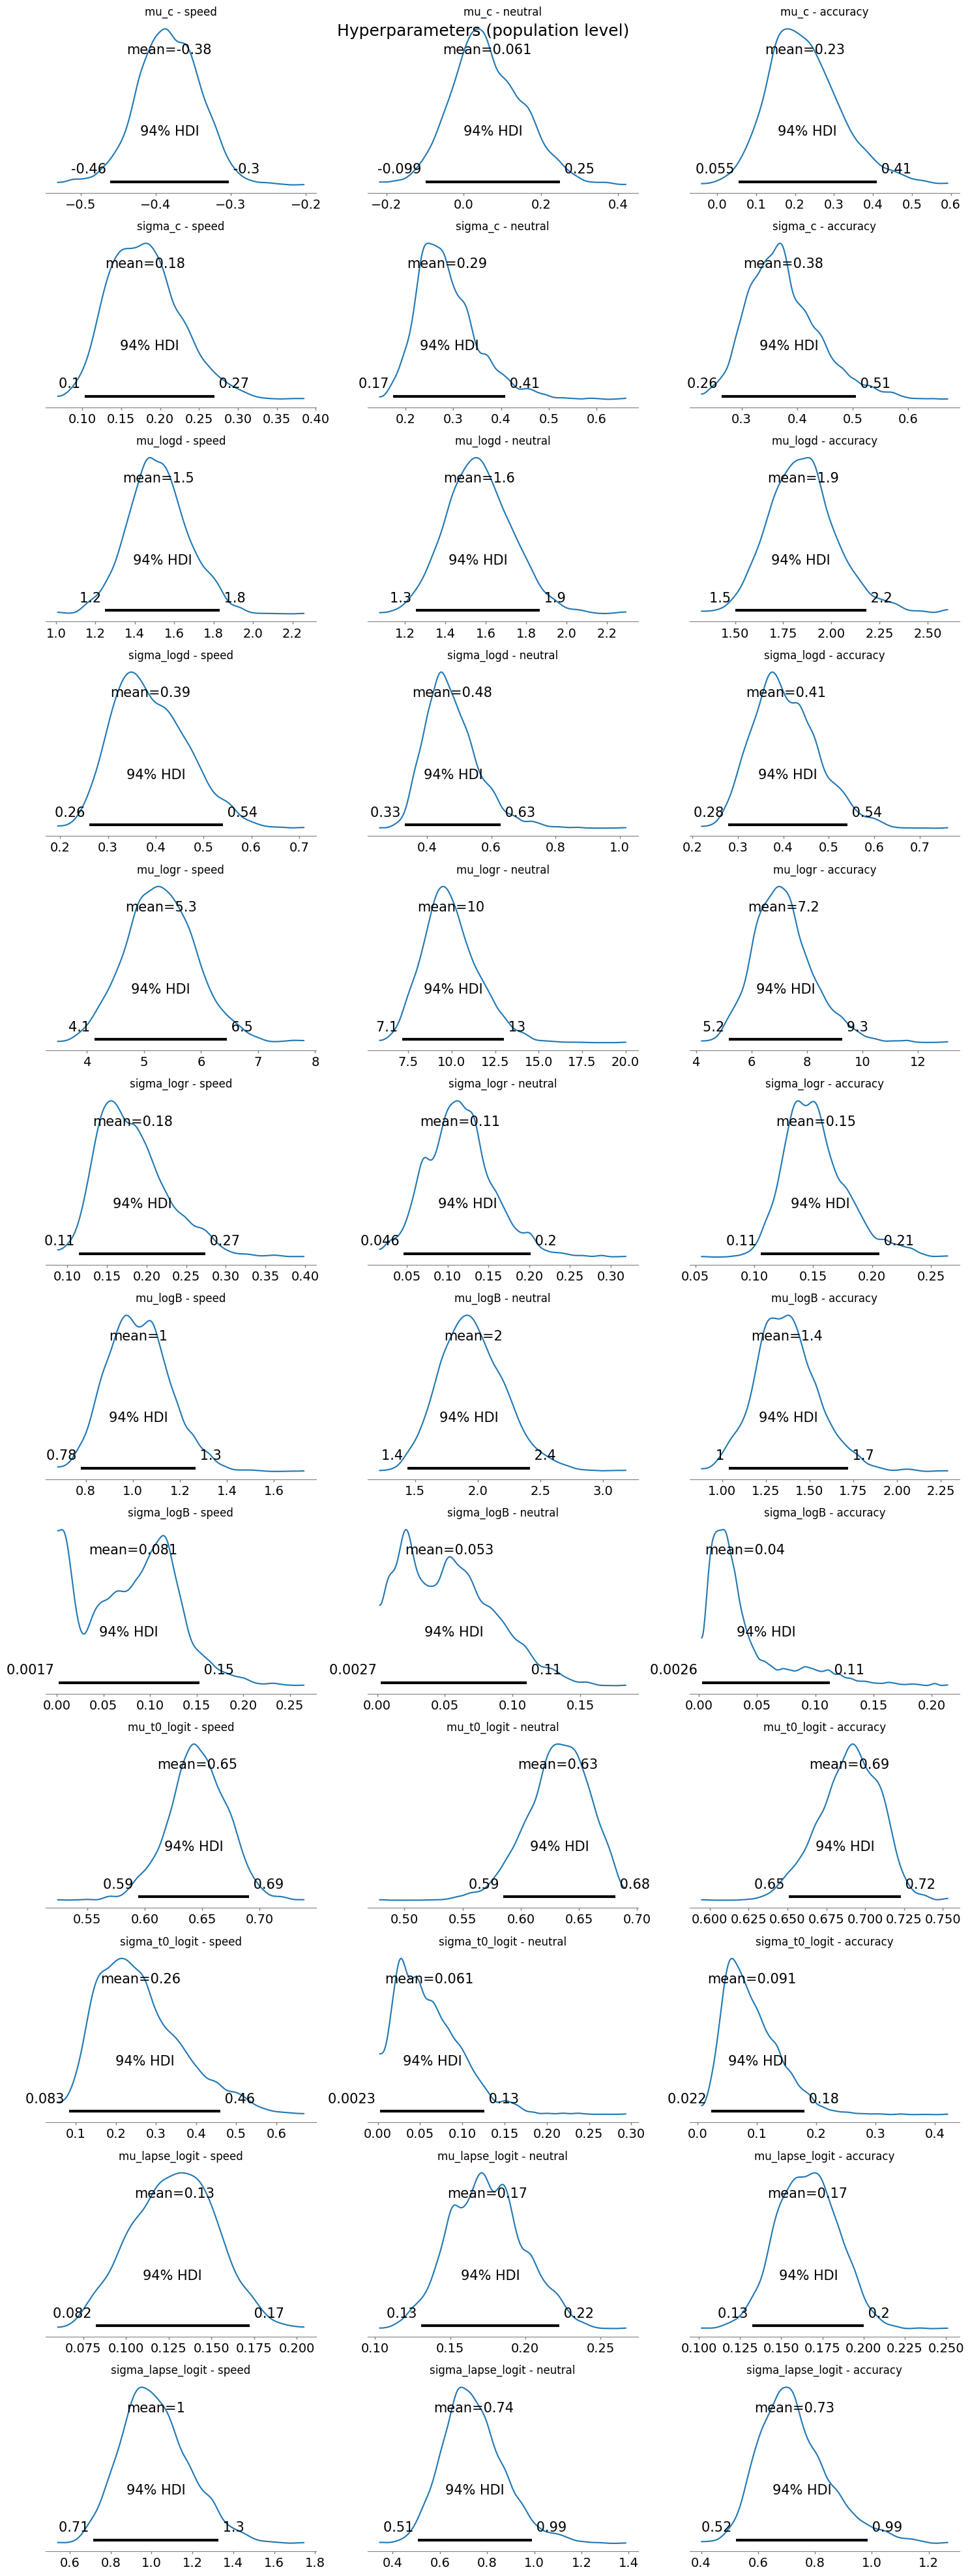

In [75]:
import matplotlib.pyplot as plt
import arviz as az
idata = az.from_cmdstanpy(fit)
cond_labels = ["speed", "neutral", "accuracy"]
hyper_pairs = [
    ("mu_c", "sigma_c"), ("mu_logd", "sigma_logd"), ("mu_logr", "sigma_logr"),
    ("mu_logB", "sigma_logB"), ("mu_t0_logit", "sigma_t0_logit"),
    ("mu_lapse_logit", "sigma_lapse_logit"),
]

import numpy as np
from scipy.special import expit  # inverse logit

# which transform undoes each hyperparameter's declared scale
transforms = {
    "mu_c": None,               # already natural scale (real-valued criterion)
    "sigma_c": None,
    "mu_logd": np.exp,          # -> population d' (median)
    "sigma_logd": None,         # spread on log scale - see note below
    "mu_logr": np.exp,          # -> population r (steps/sec)
    "sigma_logr": None,
    "mu_logB": np.exp,          # -> population B
    "sigma_logB": None,
    "mu_t0_logit": expit,       # -> fraction of t0_hi (still 0-1, not seconds - see note)
    "sigma_t0_logit": None,
    "mu_lapse_logit": expit,    # -> population lapse rate, 0-1
    "sigma_lapse_logit": None,
}

fig, axes = plt.subplots(12, 3, figsize=(15, 40))

row = 0
for mu_var, sigma_var in hyper_pairs:
    for var in (mu_var, sigma_var):
        dim = f"{var}_dim_0"
        for j, cond in enumerate(cond_labels):
            az.plot_posterior(
                idata, var_names=[var], coords={dim: [j]},
                transform=transforms[var], ax=axes[row, j]
            )
            axes[row, j].set_title(f"{var} - {cond}")
        row += 1

fig.suptitle("Hyperparameters (population level)", fontsize=18)
plt.tight_layout()
plt.show()

NameError: name 'c_dim_0' is not defined

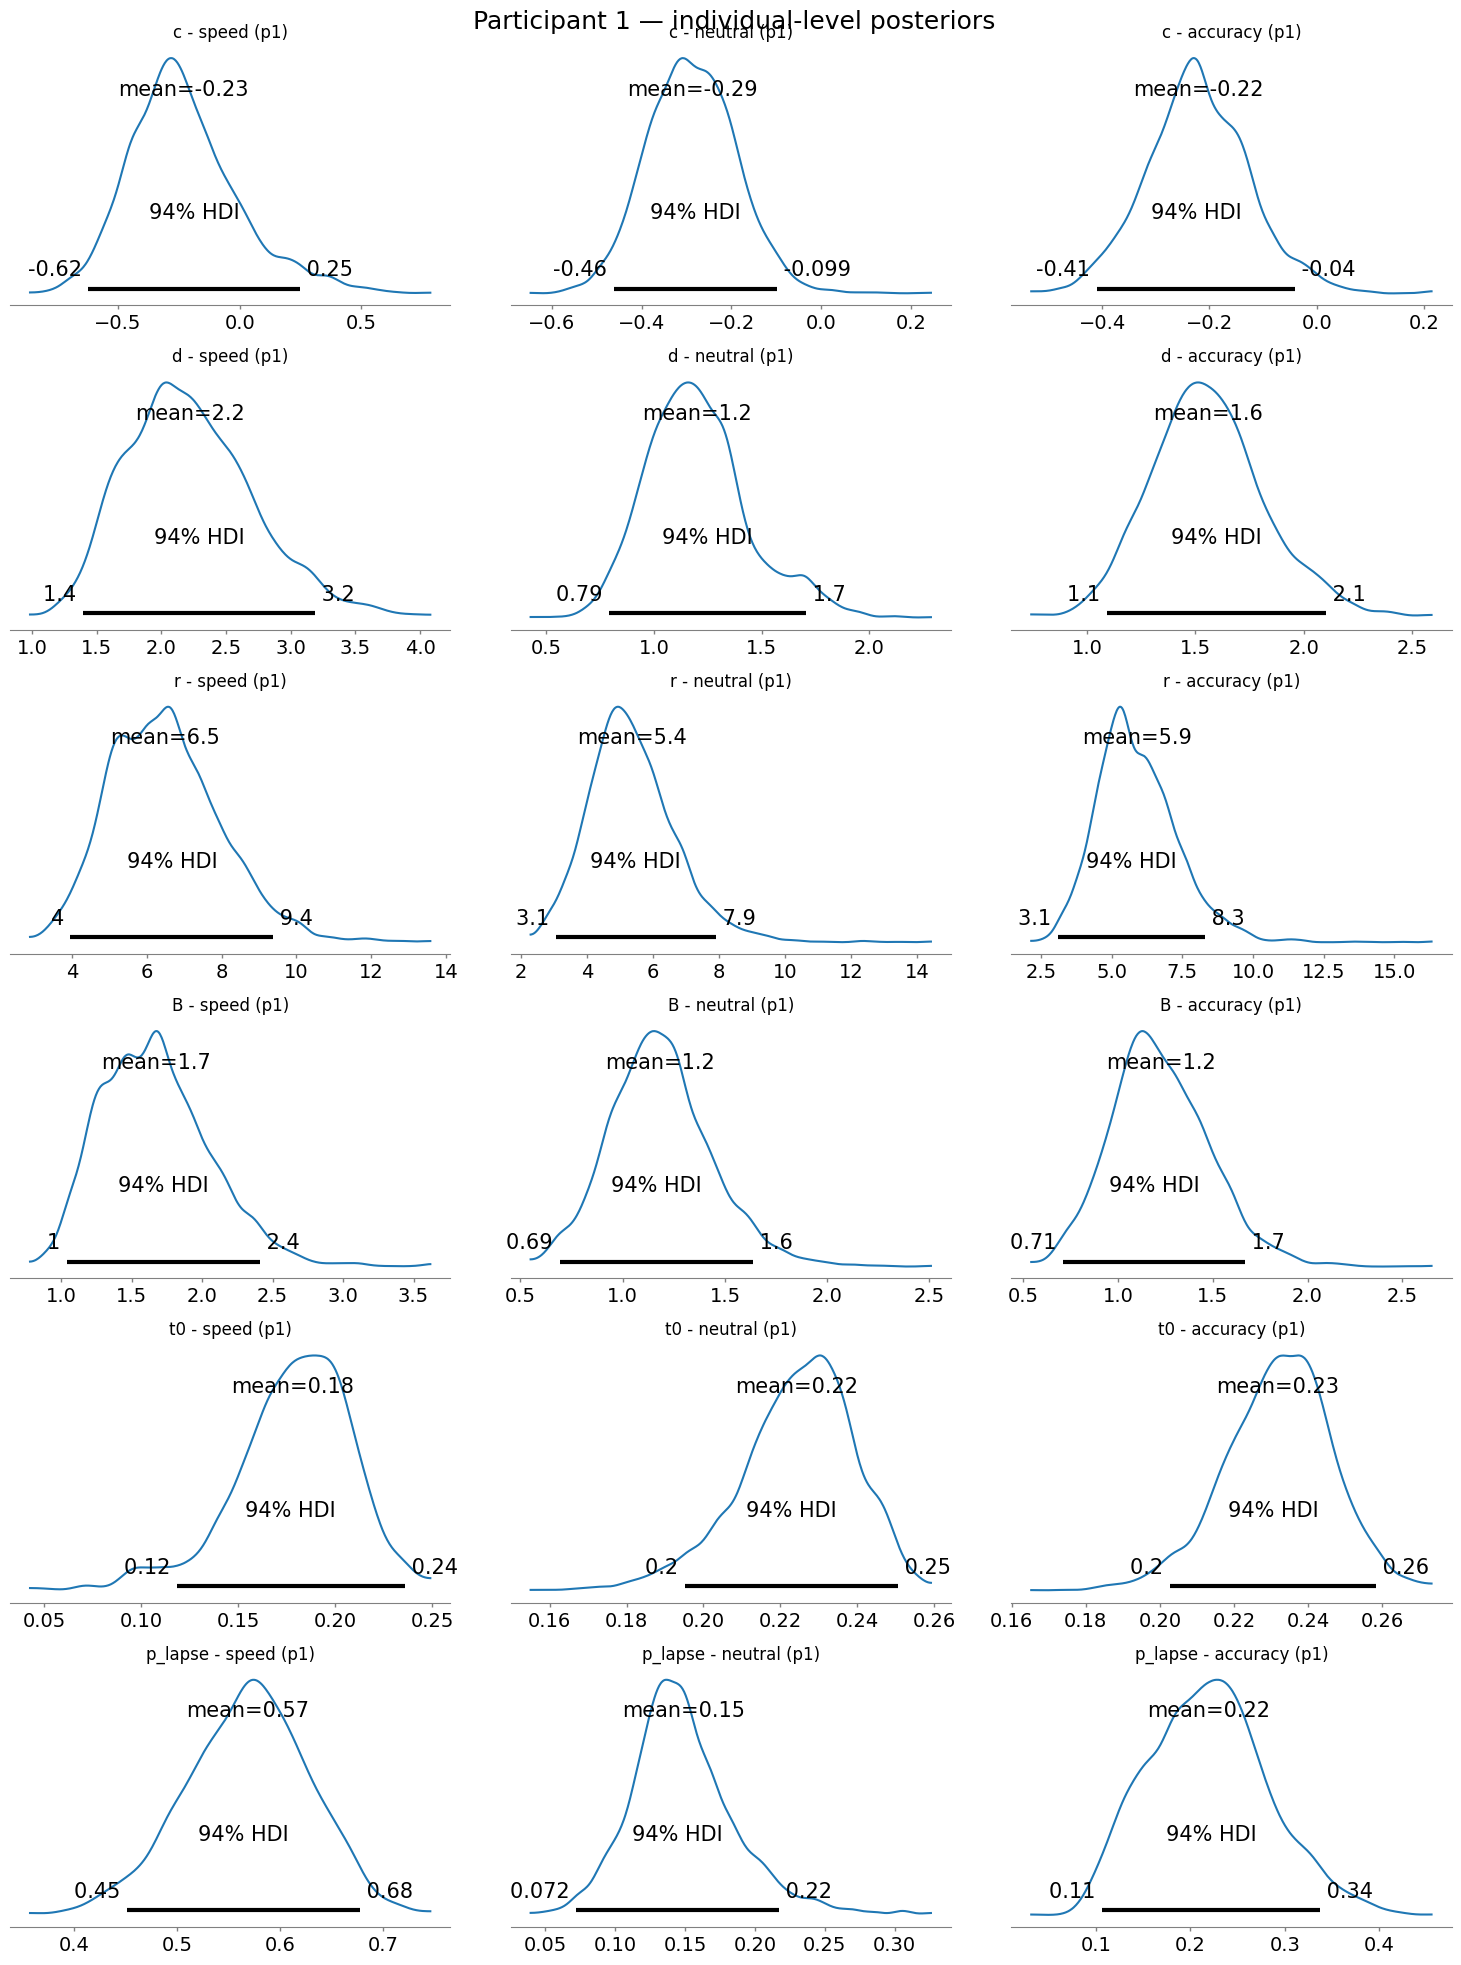

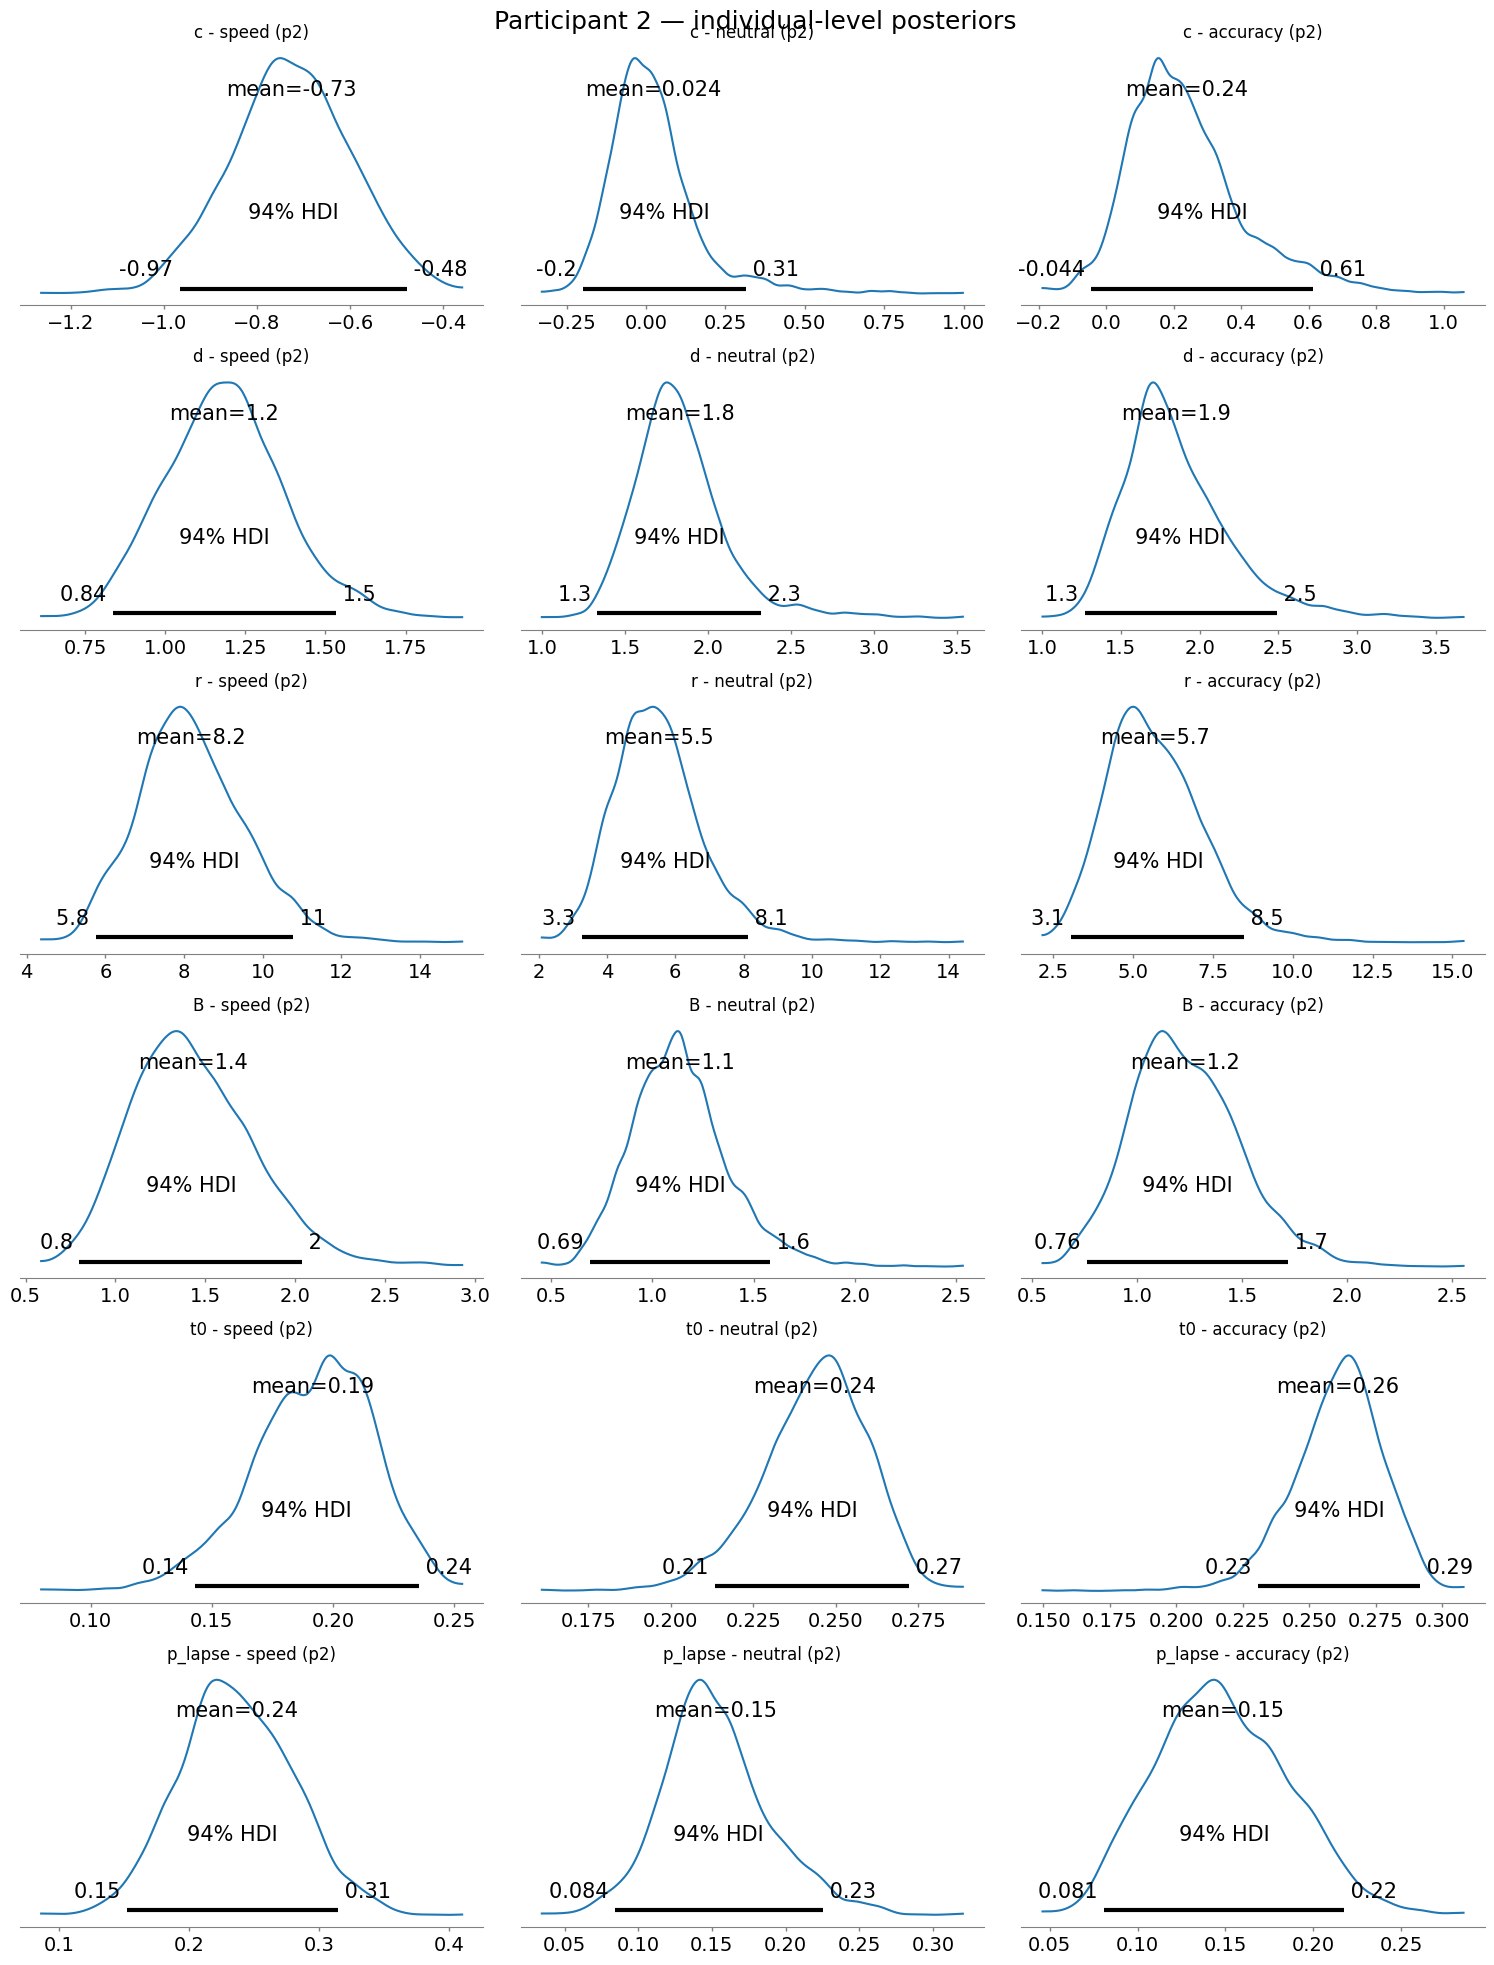

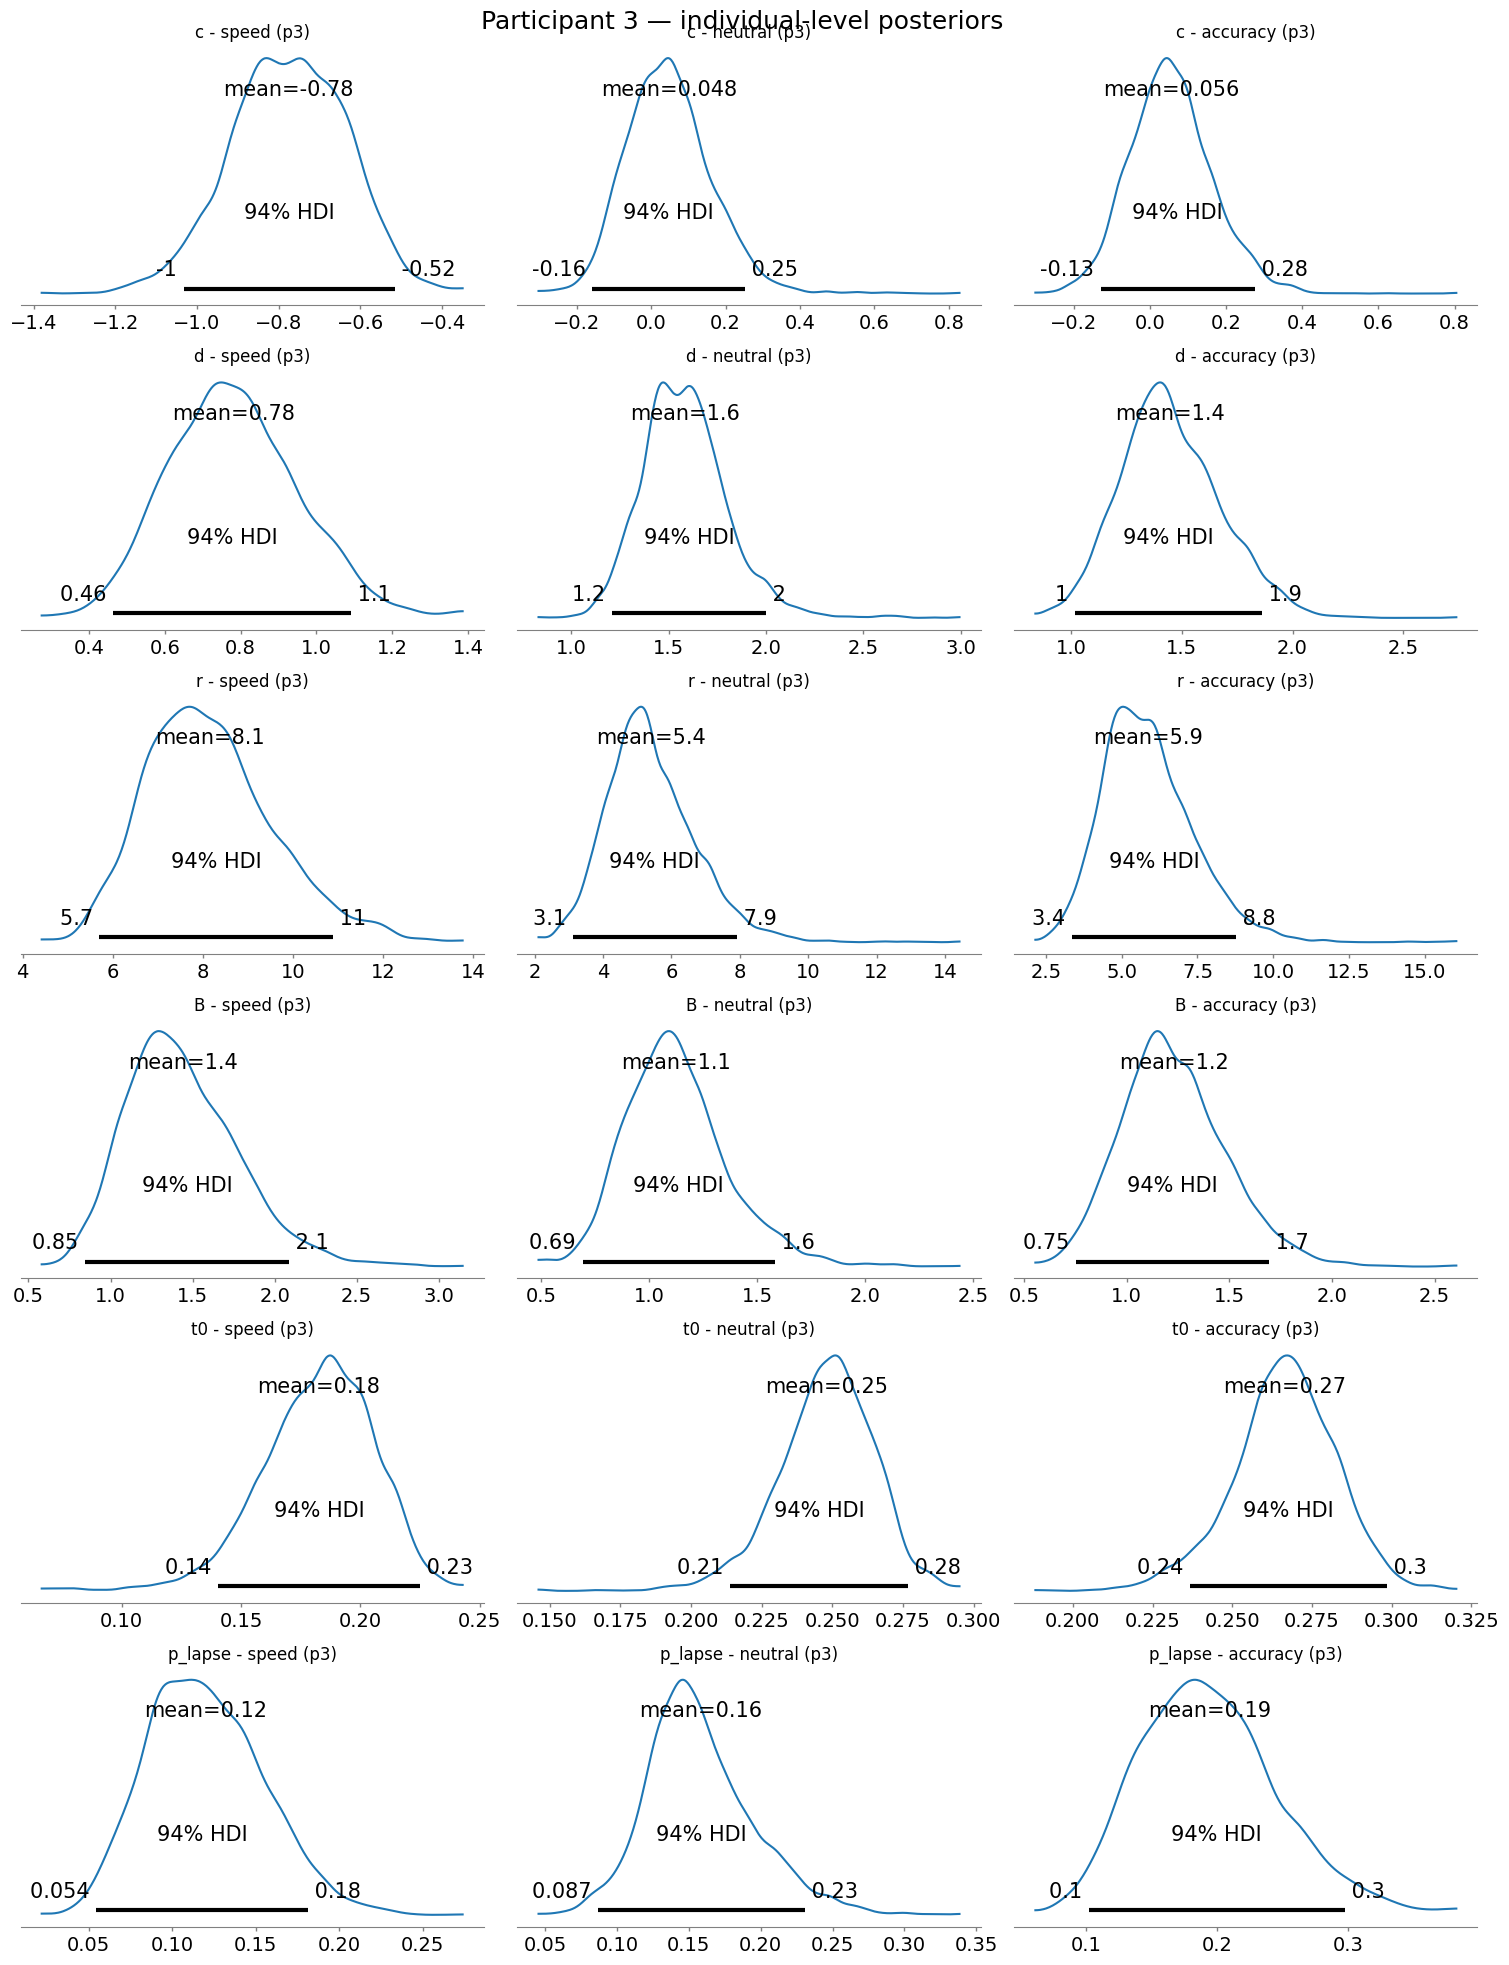

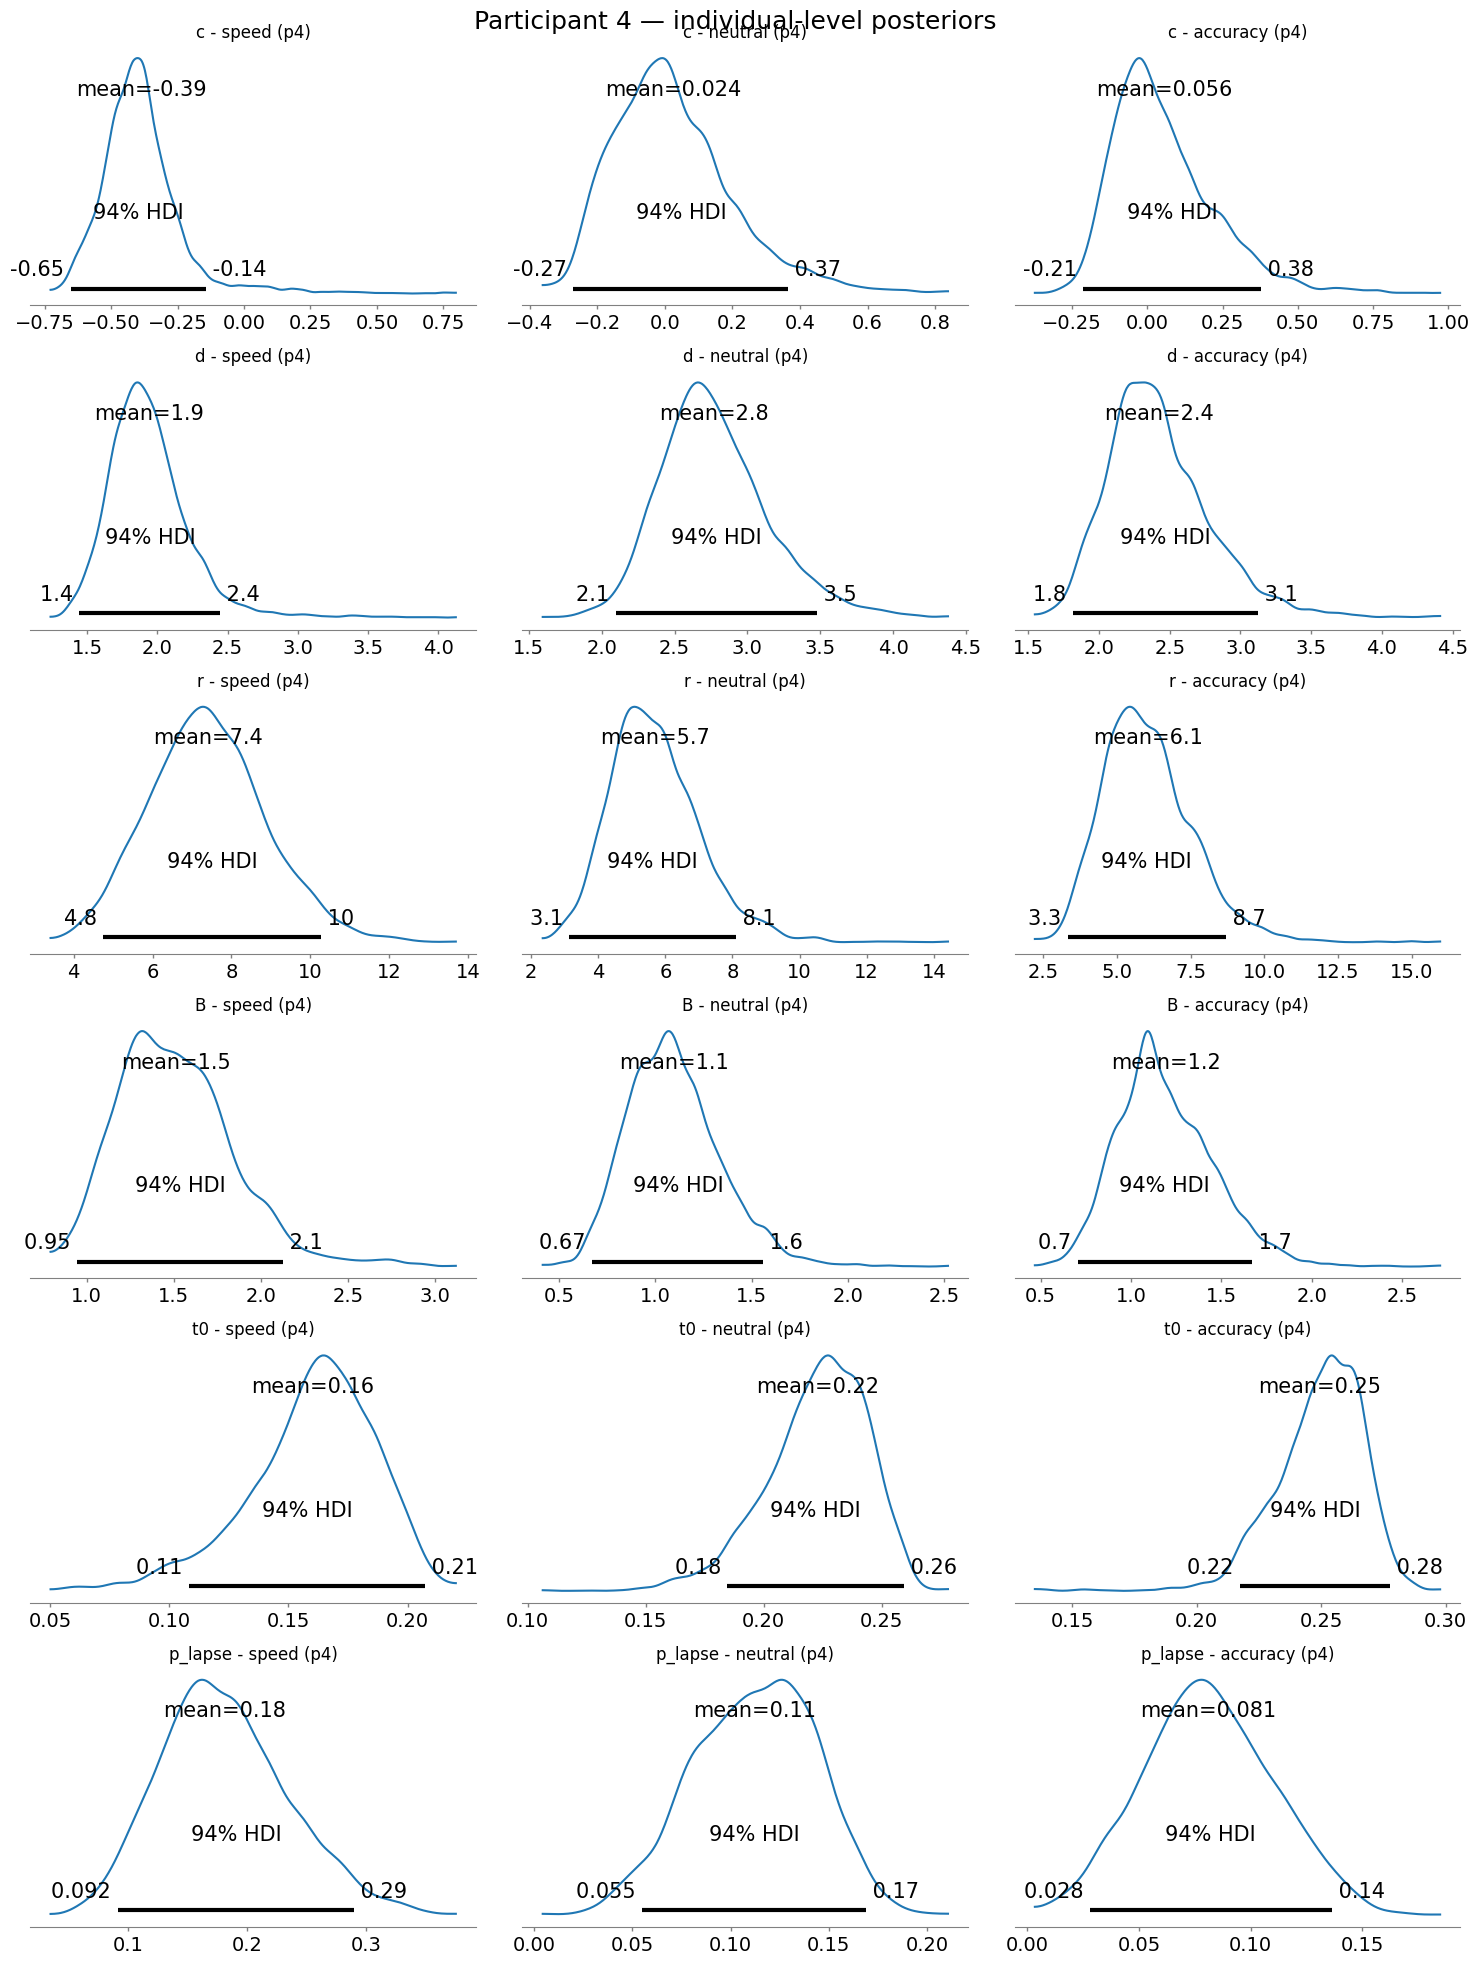

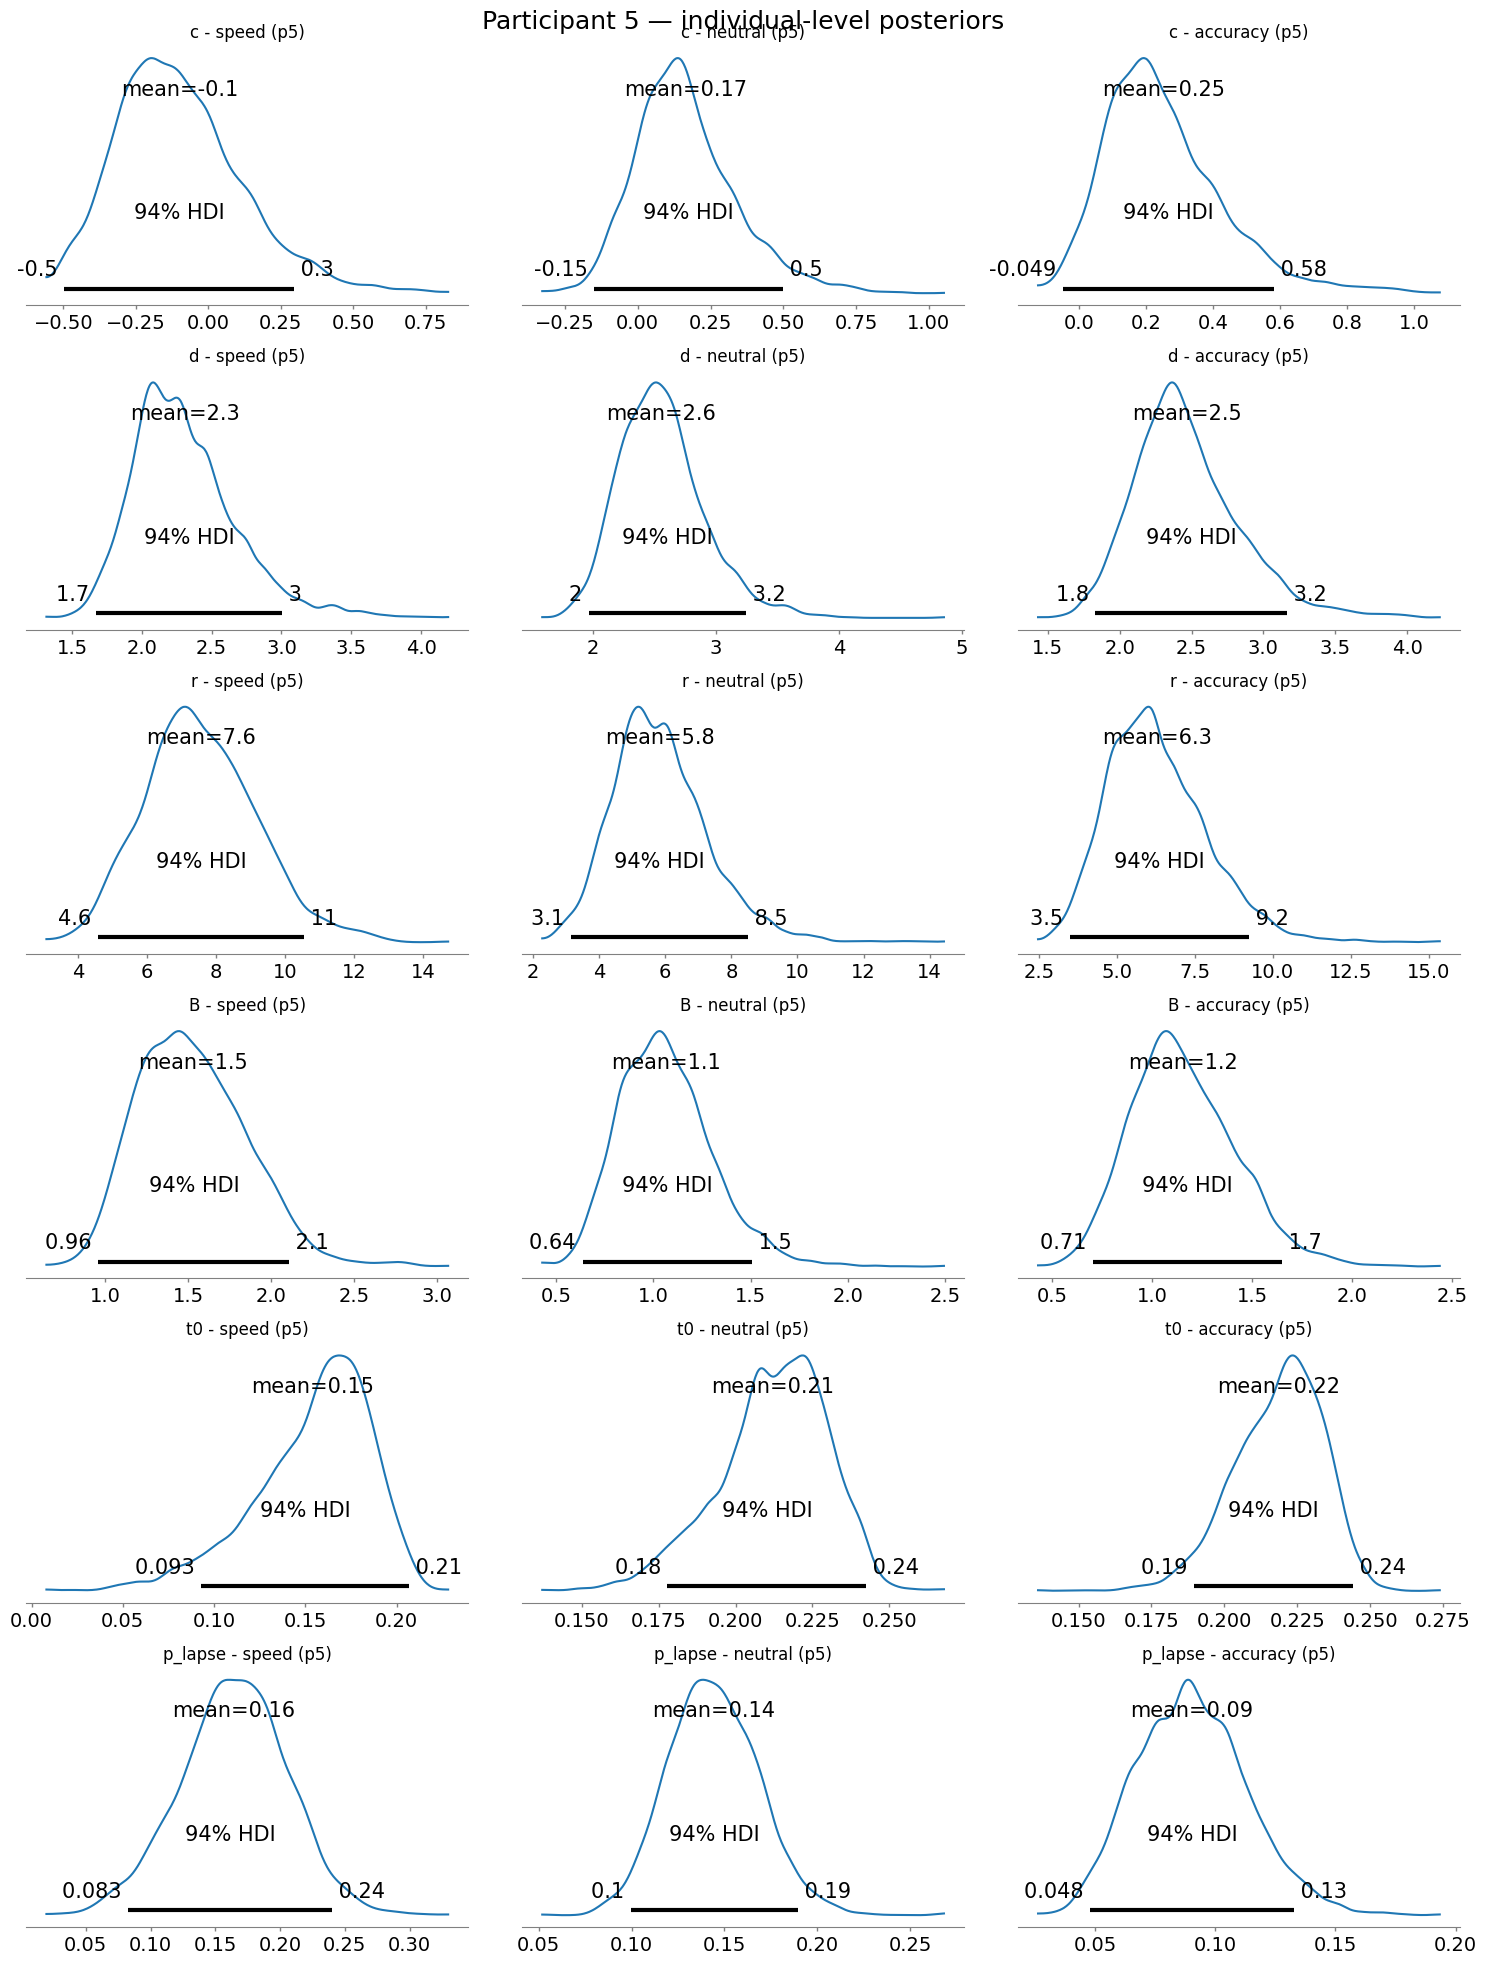

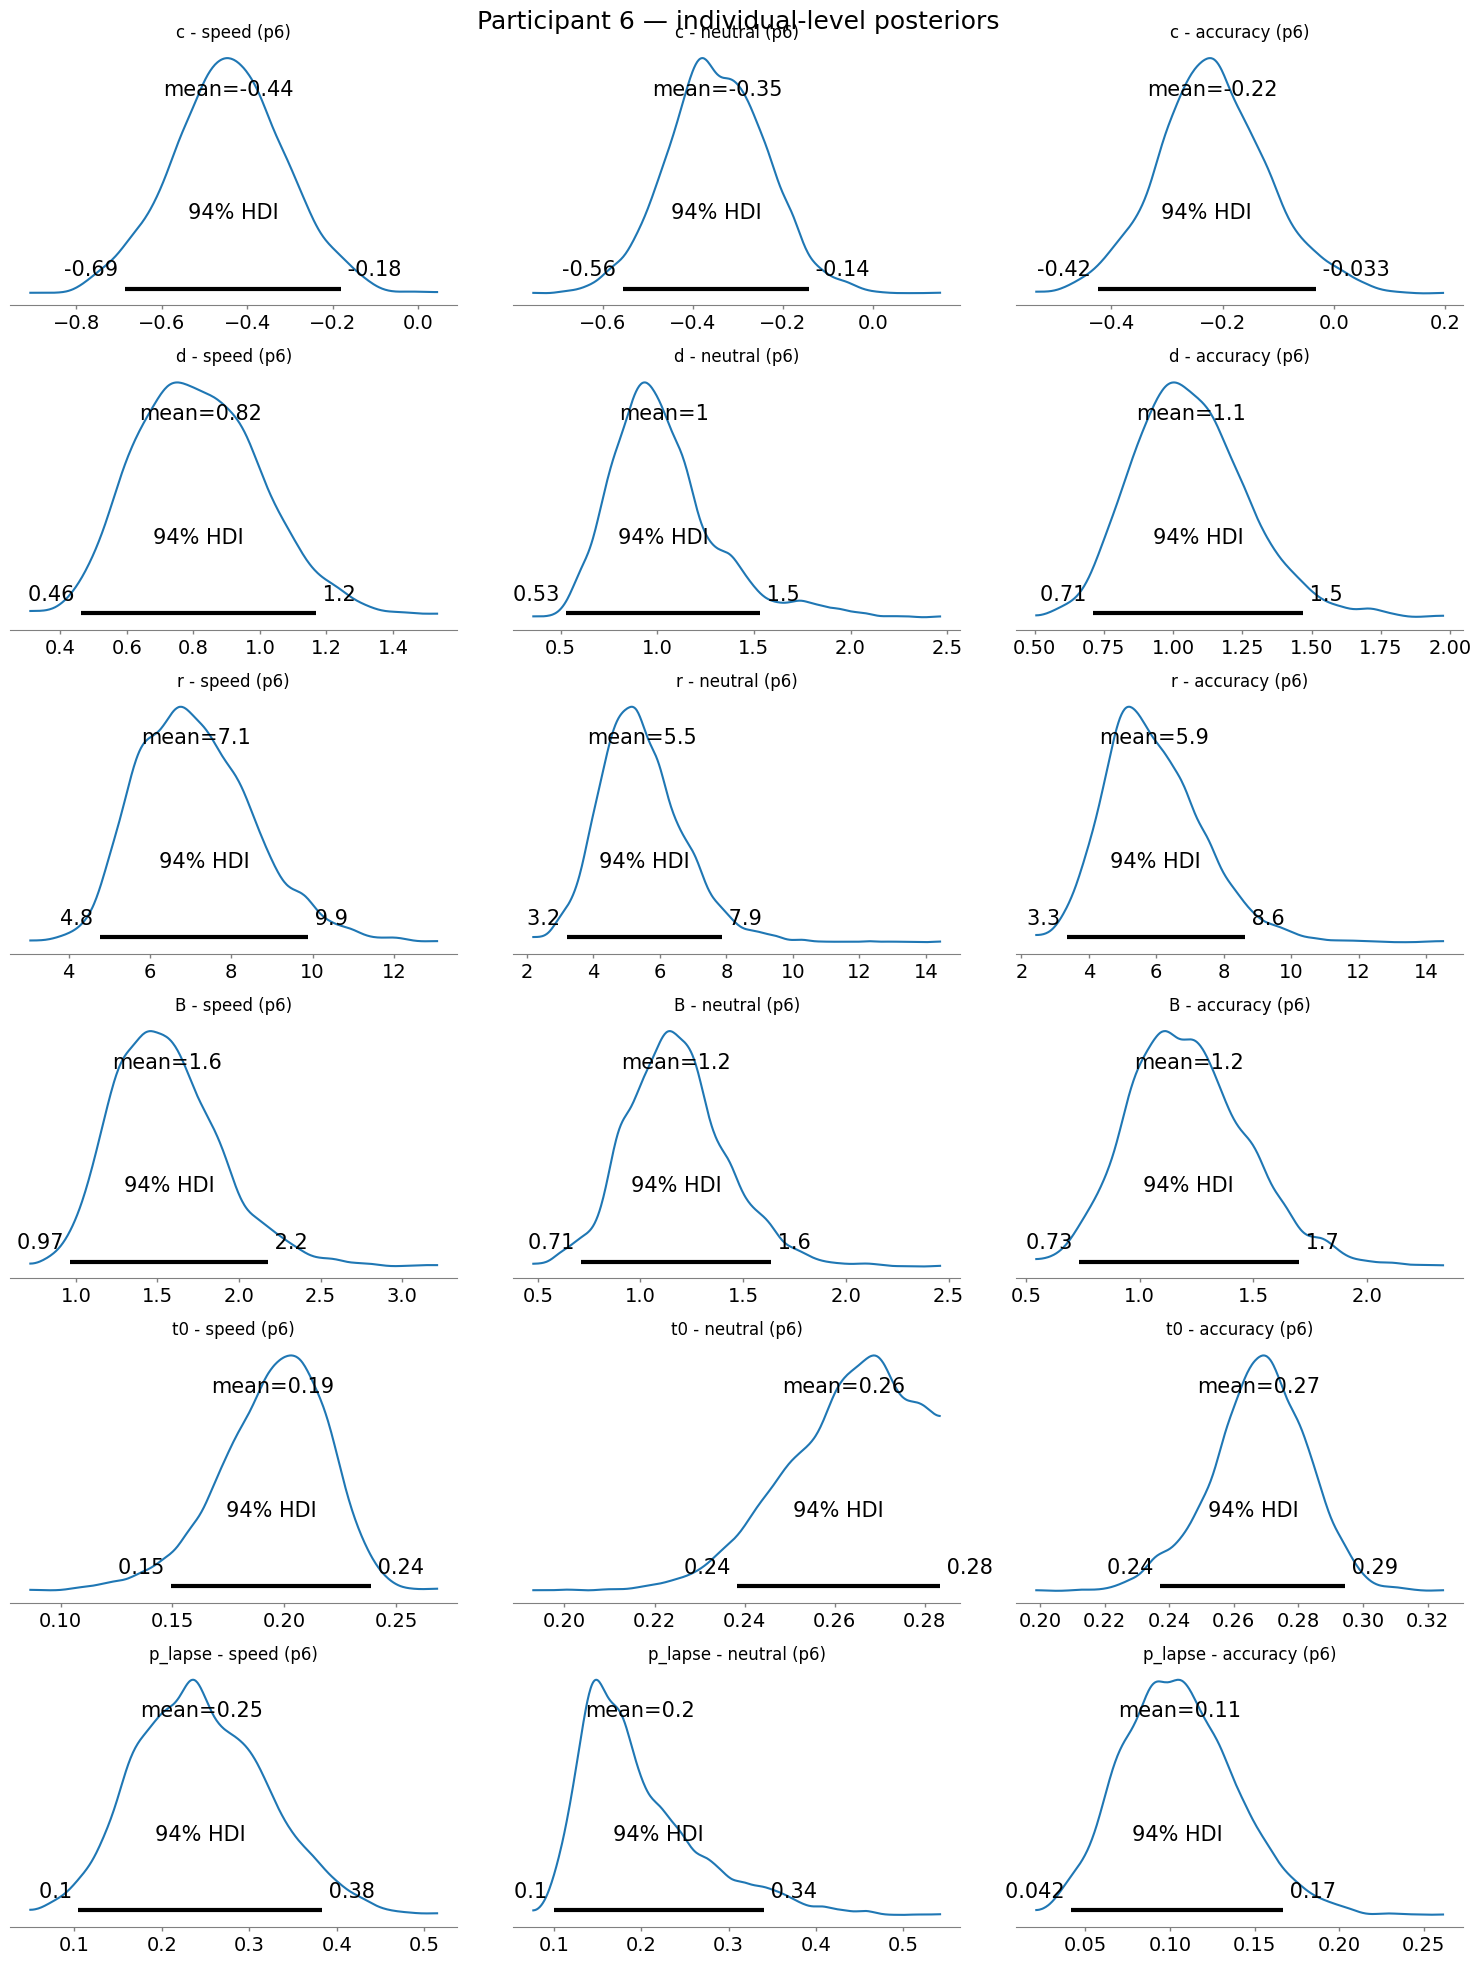

KeyError: 'Coords should follow mapping format {coord_name:[dim1, dim2]}. Check that coords structure is correct and dimensions are valid. "not all values found in index \'c_dim_0\'"'

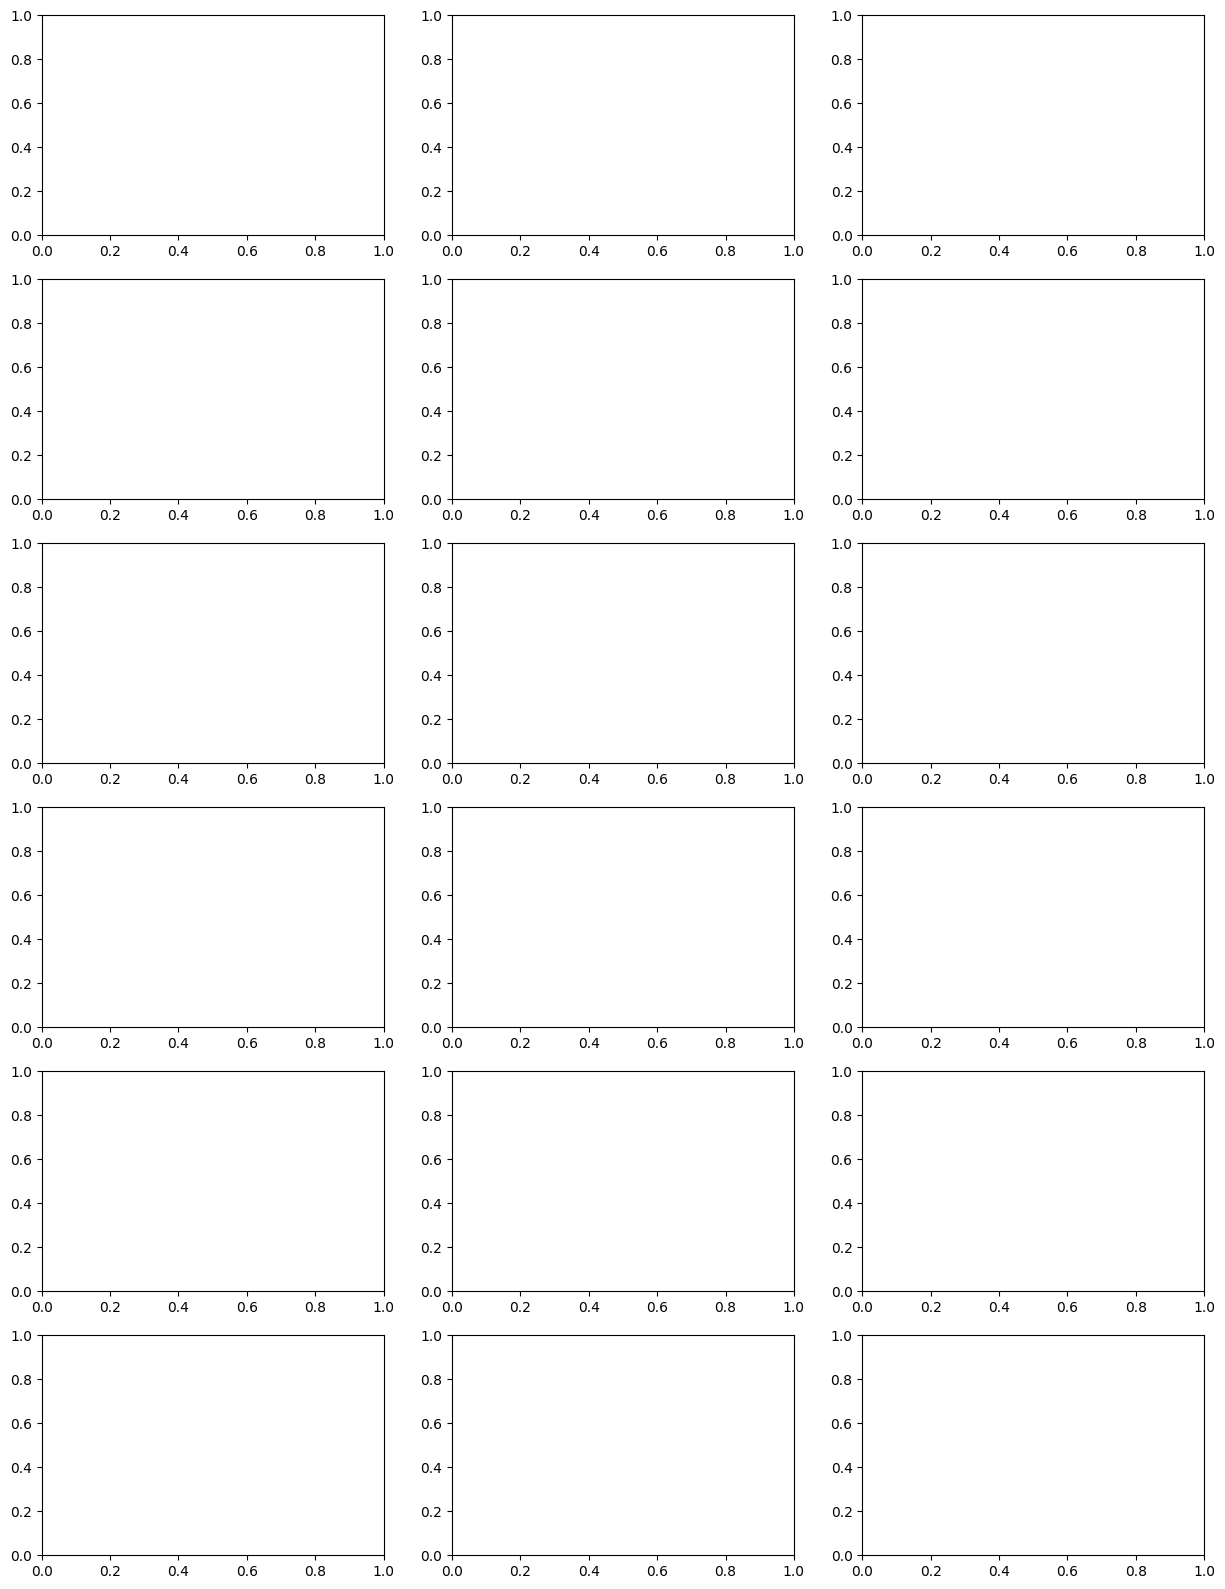

In [73]:
n_participants = 19
per_cell_vars = ["c", "d", "r", "B", "t0", "p_lapse"]  # all 3*P now, no separate scalar group

for p in range(n_participants):
    fig, axes = plt.subplots(6, 3, figsize=(15, 20))
    idx = [p*3, p*3+1, p*3+2]

    for row, var in enumerate(per_cell_vars):
        dim = f"{var}_dim_0"
        for j, cond in enumerate(cond_labels):
            az.plot_posterior(idata, var_names=[var], coords={dim: [idx[j]]}, ax=axes[row, j])
            axes[row, j].set_title(f"{var} - {cond} (p{p+1})")

    fig.suptitle(f"Participant {p+1} — individual-level posteriors", fontsize=18)
    plt.tight_layout()
    plt.show()